# Imports

In [1]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(2)

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

import math

import polars as pl

%load_ext autoreload
%autoreload 2
from net import *
from o2s.task import *
from data import *
from test_funcs import *

# Aesthetic Parameters

In [2]:
import matplotlib
matplotlib.rcParams["figure.facecolor"] = 'white'
matplotlib.rcParams["axes.facecolor"] = 'white'
matplotlib.rcParams["savefig.facecolor"] = 'white'
matplotlib.rcParams["text.color"] = 'black'
matplotlib.rcParams["axes.labelcolor"] = 'black'
matplotlib.rcParams["xtick.color"] = 'black'
matplotlib.rcParams["ytick.color"] = 'black'
matplotlib.rcParams["axes.edgecolor"] = 'black'
matplotlib.rcParams["axes.spines.right"] = False
matplotlib.rcParams["axes.spines.top"] = False
matplotlib.rcParams['font.family'] = 'cmss10'
matplotlib.rcParams['axes.formatter.use_mathtext'] = True
matplotlib.rcParams['mathtext.fontset'] = 'cm'

tick_fontsize = 18
label_fontsize = 20
title_fontsize = 28
legend_fontsize = 18
letter_fontsize = 21


cat_cmap = plt.get_cmap('Dark2')
cat_cmap_2 = plt.get_cmap('Pastel1')
cat_cmap_3 = plt.get_cmap('Accent')

sd_col = plt.get_cmap('Set2')(4)
hd_col = plt.get_cmap('Set2')(3)
ad_col = plt.get_cmap('Set2')(2)
av_col = plt.get_cmap('Set2')(1)
pos_col = plt.get_cmap('Set2')(0)

hd_cmap = plt.get_cmap('managua')
sd_cmap = plt.get_cmap('vanimo')

# Network

In [3]:
from Tasks import SD_0D
checkpoint_path = 'trained-models/1741628198.4426634-task:SD-0D/checkpoint-epochs:2100/net.pt'

checkpoint = torch.load(checkpoint_path, map_location=device)
task = Task.from_checkpoint(checkpoint)
task.config.update(device=device, tau=1, dt=0.1)
torch.set_default_dtype(torch.float64 if task.config.precise else torch.float32)
net = RNN(task)
net.load_state_dict(checkpoint['net_state_dict'])
net.state_noise_std = 0

# Figure 1

## A - Model Schematic

In [4]:
A_image = matplotlib.image.imread('1A-full.png')

## B - Model Output

In [5]:
test = task.copy(av_step_zero_prob=0)
test_batch = TaskDataset(test).get_batch()
with torch.no_grad():
    sd_0d_test_sd_target = test_batch['vars']['sd'][0,:].cpu().numpy()
    sd_0d_test_states, _, sd_0d_test_outputs = net(test_batch['inputs'], noise=test_batch['noise'])
    sd_0d_test_states, sd_0d_test_outputs = sd_0d_test_states.cpu(), sd_0d_test_outputs.cpu()
    sd_0d_test_sd_pred = torch.atan2(sd_0d_test_outputs[0, :, 0], sd_0d_test_outputs[0, :, 1]).numpy()
    sd_0d_test_sd_pred[sd_0d_test_sd_pred < 0] += 2 * np.pi
del test, test_batch, sd_0d_test_outputs

T = np.linspace(0, task.config.n_timesteps/10, task.config.n_timesteps)
dt = T[1] - T[0]
sd_0d_test_sd_pred_x = []
sd_0d_test_sd_pred_y = []
for i, (t, sd) in enumerate(zip(T, sd_0d_test_sd_pred)):
    if i == 0:
        sd_0d_test_sd_pred_x.append(t)
        sd_0d_test_sd_pred_y.append(sd)
    else:
        diff = sd - sd_0d_test_sd_pred_y[-1]
        if np.abs(diff) > np.pi:
            sd_0d_test_sd_pred_x.extend([t - dt/2, t])
            sd_0d_test_sd_pred_y.extend([np.nan, sd])
        else:
            sd_0d_test_sd_pred_x.append(t)
            sd_0d_test_sd_pred_y.append(sd)

sd_0d_test_sd_target_x = []
sd_0d_test_sd_target_y = []
for i, (t, sd) in enumerate(zip(T, sd_0d_test_sd_target)):
    if i == 0:
        sd_0d_test_sd_target_x.append(t)
        sd_0d_test_sd_target_y.append(sd)
    else:
        diff = sd - sd_0d_test_sd_target_y[-1]
        if np.abs(diff) > np.pi:
            sd_0d_test_sd_target_x.extend([t - dt/2, t])
            sd_0d_test_sd_target_y.extend([np.nan, sd])
        else:
            sd_0d_test_sd_target_x.append(t)
            sd_0d_test_sd_target_y.append(sd)

# C, D, E - Tuning

In [6]:
tuning_batch_size = 5000
tuning_vars_list = ['HD', 'ego_SD', 'allo_SD', 'AV']
n_diff_bins = 50
sd_0d_example_neurons = [0, 7]

In [7]:
tuning_task = Task.from_checkpoint(checkpoint)
tuning_task.config.update(batch_size=tuning_batch_size, device=device, rank=0 if tuning_task.config.rank is None else int(tuning_task.config.rank))
tuning_batch = TaskDataset(tuning_task, include_noise=False).get_batch()
with torch.no_grad():
    activity = net(tuning_batch['inputs'], offload=True)[1].detach().cpu().numpy()
inputs, targets, vars = tuning_batch['inputs'].cpu().numpy(), tuning_batch['targets'].cpu().numpy(), {k: v.cpu().numpy() for k,v in tuning_batch['vars'].items()}
sd_0d_tuning_vars, sd_0d_tuning_dict = get_tuning_generalised(tuning_task, inputs, targets, vars, activity, tuning_vars_list)
del inputs, targets, vars, activity, tuning_batch, tuning_task
sd_0d_coefs = fit_tuning_curves(sd_0d_tuning_vars, sd_0d_tuning_dict)

sd_0d_mean_tuning_scaled_weights = np.full((3, 3, 2, n_diff_bins,), np.nan)
sd_0d_sem_tuning_scaled_weights = np.full((3, 3, 2, n_diff_bins,), np.nan)

hd_coefs, sd_coefs, ad_coefs, av_coefs = sd_0d_coefs['HD'], sd_0d_coefs['ego_SD'], sd_0d_coefs['allo_SD'], sd_0d_coefs['AV']
W_rec = net.W_rec.weight.detach().cpu().numpy()

for i, pre in enumerate(['hd', 'sd', 'ad']):

    row_axes = []
    for j, post in enumerate(['hd', 'sd', 'ad']):
        W_rec_tuned = None

        pre_phases = None

        pre_angle_tuning = None
        pre_av_tuning = None
        if pre=='hd':
            pre_phases = hd_coefs[:, 1]

            pre_angle_tuning = hd_coefs[:, 0]
            pre_av_tuning = av_coefs[:, 0]
        elif pre=='sd':
            pre_phases = sd_coefs[:, 1]

            pre_angle_tuning = sd_coefs[:, 0]
            pre_av_tuning = av_coefs[:, 0]
        elif pre=='ad':
            pre_phases = ad_coefs[:, 1]

            pre_angle_tuning = ad_coefs[:, 0]
            pre_av_tuning = av_coefs[:, 0]
        pre_phases[pre_phases<0] += 2*np.pi

        post_phases = None

        post_angle_tuning = None
        post_av_tuning = None
        if post=='hd':
            post_phases = hd_coefs[:, 1]

            post_angle_tuning = hd_coefs[:, 0]
            post_av_tuning = av_coefs[:, 0]
        elif post=='sd':
            post_phases = sd_coefs[:, 1]

            post_angle_tuning = sd_coefs[:, 0]
            post_av_tuning = av_coefs[:, 0]
        elif post=='ad':
            post_phases = ad_coefs[:, 1]

            post_angle_tuning = ad_coefs[:, 0]
            post_av_tuning = av_coefs[:, 0]
        post_phases[post_phases<0] += 2*np.pi
        
        pre_order, post_order = np.argsort(pre_phases), np.argsort(post_phases)
        pre_i, post_i = np.meshgrid(pre_order, post_order)
        pre_i, post_i = pre_i.flatten(), post_i.flatten()

        equal_mask = pre_i == post_i
        pre_i = pre_i[~equal_mask]
        post_i = post_i[~equal_mask]

        diff = np.remainder(post_phases[post_i] - pre_phases[pre_i], 2*np.pi)

        diff_bins = np.linspace(0, 2*np.pi, n_diff_bins+2)[1:-1]
        diff_bins_i = np.digitize(diff, diff_bins)

        synapses = W_rec[post_i, pre_i]

        for k in range(n_diff_bins):
            bin_mask = diff_bins_i == k

            angle_scaled_synapses = synapses * pre_angle_tuning[pre_i] # * post_angle_tuning[post_i]
            av_scaled_synapses = synapses * pre_av_tuning[pre_i] # * post_av_tuning[post_i]

            sd_0d_mean_tuning_scaled_weights[i, j, 0, k] = np.mean(angle_scaled_synapses[bin_mask])
            sd_0d_sem_tuning_scaled_weights[i, j, 0, k] = np.std(angle_scaled_synapses[bin_mask]) / np.sqrt(np.sum(bin_mask))

            sd_0d_mean_tuning_scaled_weights[i, j, 1, k] = np.mean(av_scaled_synapses[bin_mask])
            sd_0d_sem_tuning_scaled_weights[i, j, 1, k] = np.std(av_scaled_synapses[bin_mask]) / np.sqrt(np.sum(bin_mask))

Computing tuning curves
	Completed AV
	Completed AV and HD
	Completed AV and ego_SD
	Completed AV and allo_SD
	Completed HD
	Completed HD and ego_SD
	Completed HD and allo_SD
	Completed ego_SD
	Completed ego_SD and allo_SD
	Completed allo_SD


## Result

(0.0, 1.0, 0.0, 1.0)

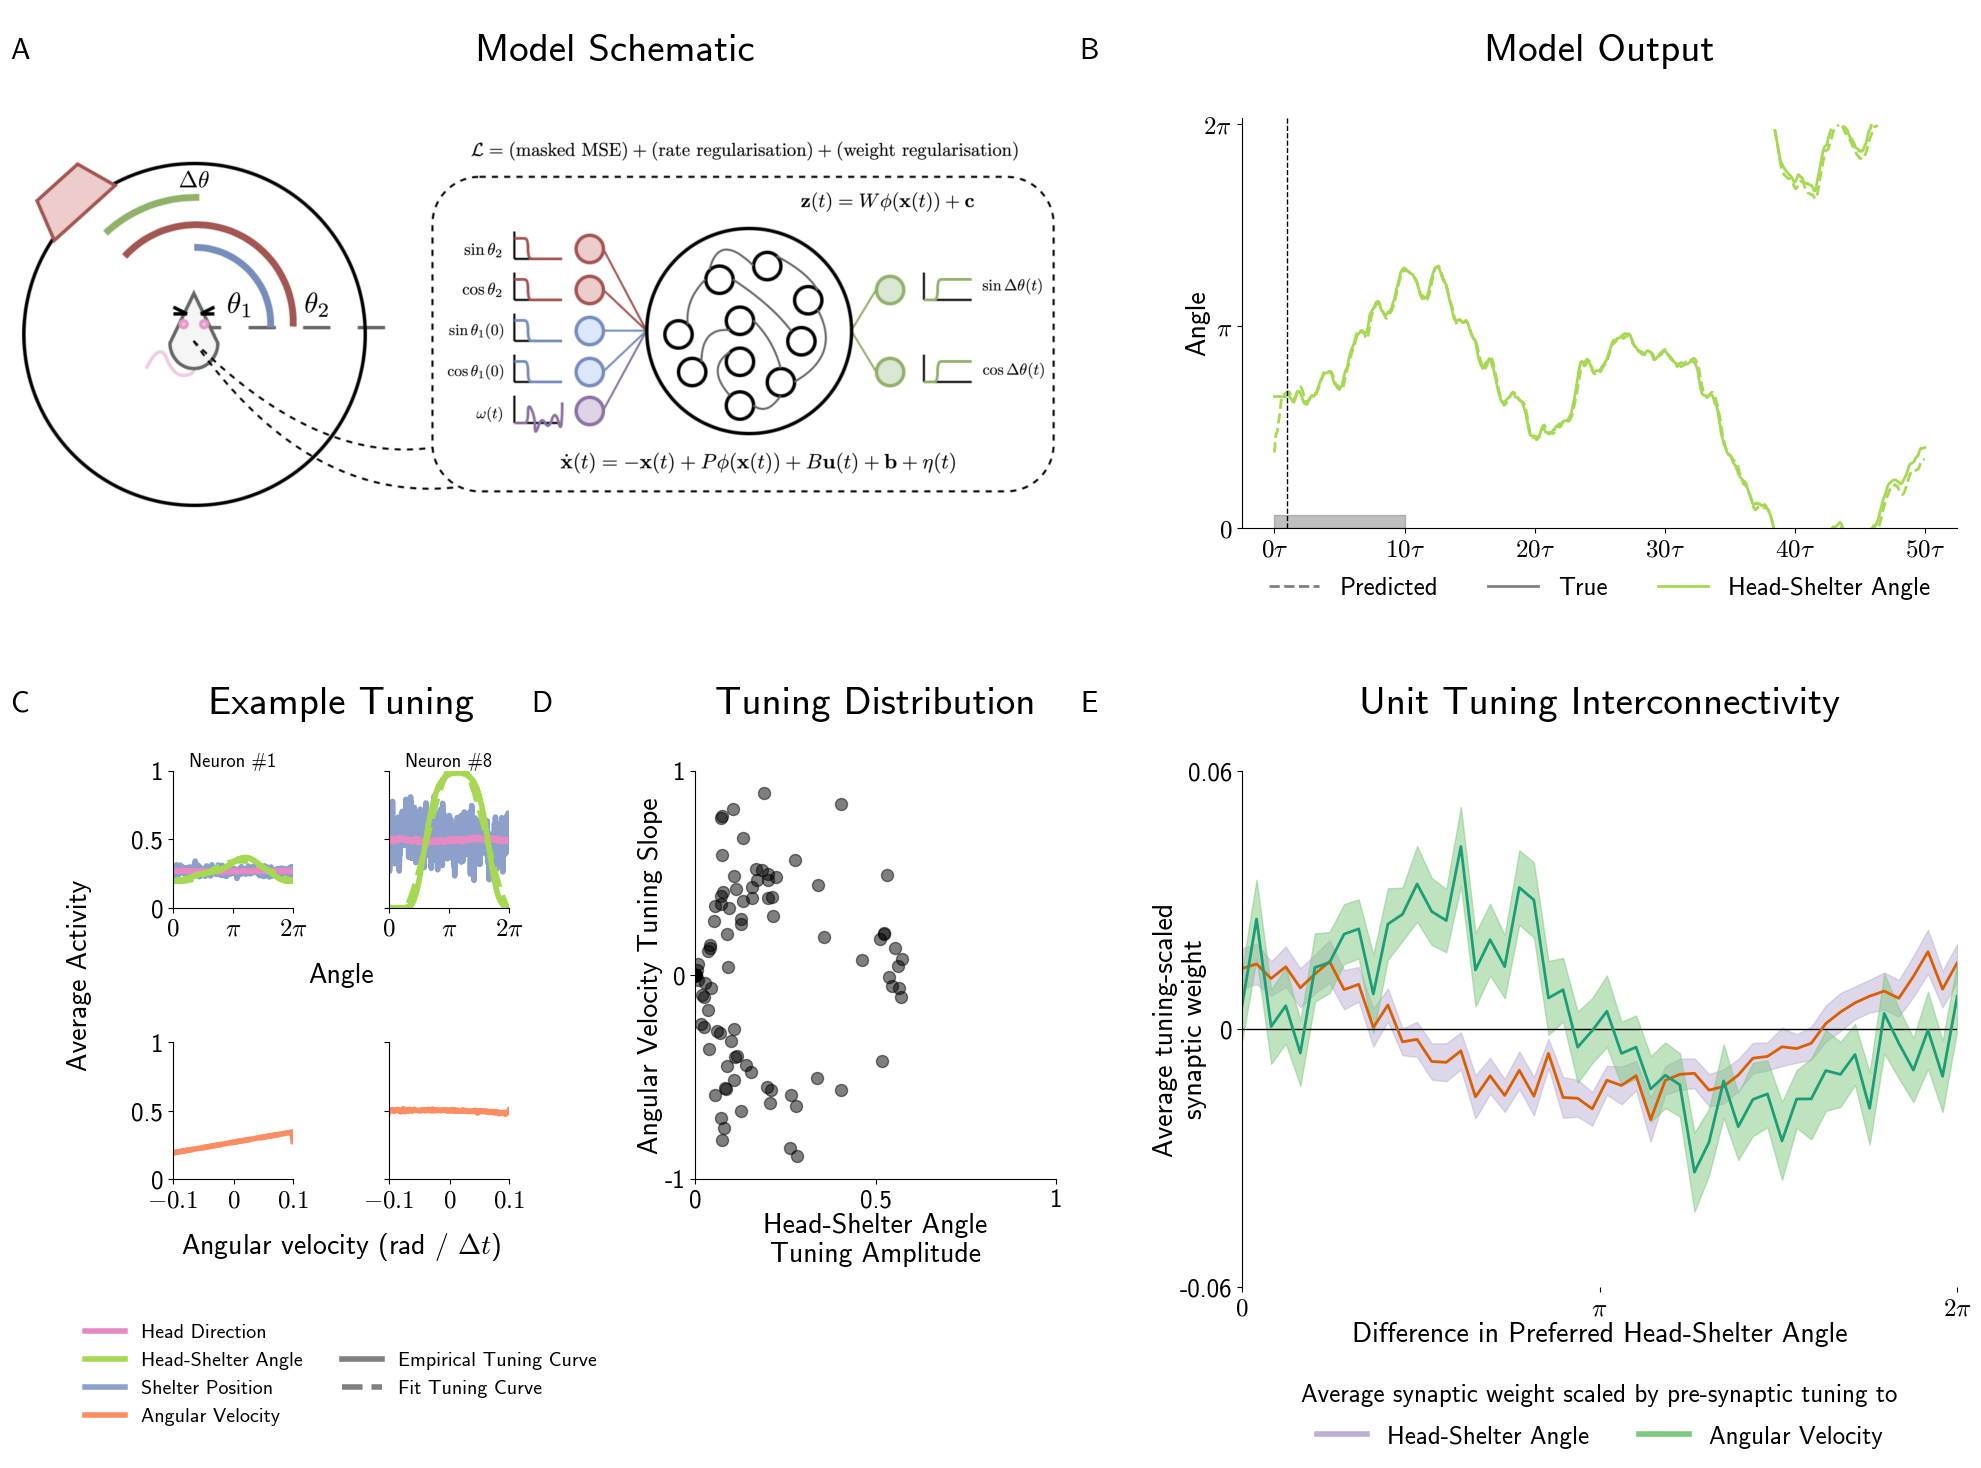

In [15]:
v_spacer = 0.3
h_spacer = 0.5

fig = plt.figure(figsize=(25, 18))
gs = fig.add_gridspec(9, 10, height_ratios=[v_spacer, 1.5, 0.3, v_spacer, 0.5, v_spacer, 0.5, v_spacer, 0.3], width_ratios=[h_spacer, 0.5, h_spacer/4, 0.5, h_spacer, 1.5, h_spacer, 1.1, h_spacer, 1.1])

A_top_row = 0
A_bottom_row = 2
A_left_col = 0
A_right_col = 5

B_top_row = 0
B_bottom_row = 2
B_left_col = 6
B_right_col = 9

C_top_row = 3
C_bottom_row = 8
C_left_col = 0
C_right_col = 3

D_top_row = 3
D_bottom_row = 6
D_left_col = 4
D_right_col = 5

E_top_row = 3
E_bottom_row = 8
E_left_col = 6
E_right_col = 9

A_letter_ax = fig.add_subplot(gs[A_top_row, A_left_col])
A_letter_ax.text(0, 0.5, 'A', fontsize=letter_fontsize, fontweight='bold', ha='center', va='center', rotation=0)
A_letter_ax.set_xlim([0,1])
A_letter_ax.axis('off')
A_title_ax = fig.add_subplot(gs[A_top_row, A_left_col+1:A_right_col+1])
A_title_ax.text(0.5, 0.5, 'Model Schematic', fontsize=title_fontsize, fontweight='regular', ha='center', va='center')
A_title_ax.set_xlim([0,1])
A_title_ax.axis('off')

A_data_ax = fig.add_subplot(gs[A_top_row+1, A_left_col:A_right_col+1])
A_data_ax.imshow(A_image, aspect='equal')
A_data_ax.axis('off')


B_letter_ax = fig.add_subplot(gs[B_top_row, B_left_col])
B_letter_ax.text(0, 0.5, 'B', fontsize=letter_fontsize, fontweight='bold', ha='center', va='center', rotation=0)
B_letter_ax.set_xlim([0,1])
B_letter_ax.axis('off')
B_title_ax = fig.add_subplot(gs[B_top_row, B_left_col+1:B_right_col+1])
B_title_ax.text(0.5, 0.5, 'Model Output', fontsize=title_fontsize, fontweight='regular', ha='center', va='center')
B_title_ax.set_xlim([0,1])
B_title_ax.axis('off')

B_data_ax = fig.add_subplot(gs[B_top_row+1, B_left_col+1:B_right_col+1])
B_data_ax.plot(sd_0d_test_sd_pred_x, sd_0d_test_sd_pred_y, lw=2, linestyle='--', color=sd_col)
B_data_ax.plot(sd_0d_test_sd_target_x, sd_0d_test_sd_target_y, lw=2, linestyle='-', color=sd_col)
B_data_ax.axvline(x=1, color='k', linestyle='--', lw=1)
B_data_ax.set_xticks([0, 10, 20, 30, 40, 50])
B_data_ax.set_xticklabels([r'$0\tau$', r'$10\tau$', r'$20\tau$', r'$30\tau$', r'$40\tau$', r'$50\tau$'], fontsize=tick_fontsize)
B_data_ax.set_yticks([0, np.pi, 2*np.pi])
B_data_ax.set_ylim([0, 2*np.pi + 0.1])
B_data_ax.set_yticklabels([r'$0$', r'$\pi$', r'$2\pi$'], fontsize=tick_fontsize)
B_data_ax.fill_between([0, 10], 0, 0.2, color='gray', alpha=0.5)
B_data_ax.set_ylabel('Angle', fontsize=label_fontsize, ha='center', va='center', rotation=90)


B_legend_ax = fig.add_subplot(gs[B_bottom_row, B_left_col+1:B_right_col+1])
B_handles = [
    matplotlib.lines.Line2D([0], [0], lw=2, linestyle='--', color='gray', label='Predicted'),
    matplotlib.lines.Line2D([0], [0], lw=2, linestyle='-', color='gray', label='True'),
    matplotlib.lines.Line2D([0], [0], lw=2, linestyle='-', color=sd_col, label='Head-Shelter Angle'),
]
B_legend_ax.legend(handles=B_handles, loc='upper center', fontsize=legend_fontsize, frameon=False, ncol=3)
B_legend_ax.axis('off')


C_letter_ax = fig.add_subplot(gs[C_top_row, C_left_col])
C_letter_ax.text(0, 0.5, 'C', fontsize=letter_fontsize, fontweight='bold', ha='center', va='center', rotation=0)
C_letter_ax.set_xlim([0,1])
C_letter_ax.axis('off')
C_title_ax = fig.add_subplot(gs[C_top_row, C_left_col+1:C_right_col+1])
C_title_ax.text(0.5, 0.5, 'Example Tuning', fontsize=title_fontsize, fontweight='regular', ha='center', va='center')
C_title_ax.set_xlim([0,1])
C_title_ax.axis('off')

tuning_vars, tuning_dict, example_neurons, network = sd_0d_tuning_vars, sd_0d_tuning_dict, sd_0d_example_neurons, 'Head-Shelter Network'
angle_x = tuning_vars['HD']['bins'] * (np.pi/180)
for i in range(2):
    ax = fig.add_subplot(gs[C_top_row+1, C_left_col+1 + 2*i])
    ax.plot(angle_x, tuning_dict['allo_SD_tuning'][example_neurons[i]], color=ad_col, lw=4)
    ax.plot(angle_x, tuning_dict['HD_tuning'][example_neurons[i]], color=hd_col, lw=4)
    ax.plot(angle_x, tuning_dict['ego_SD_tuning'][example_neurons[i]], color=sd_col, lw=4)

    sd_coefs = sd_0d_coefs['ego_SD'][example_neurons[i]]
    ax.plot(angle_x, sd_coefs[0] * np.cos(angle_x + sd_coefs[1]) + sd_coefs[2], color=sd_col, lw=4, linestyle='--')

    ax.set_ylim([0, 1])
    ax.set_yticks([0, 0.5, 1])
    if i==0:
        ax.set_yticklabels([0, 0.5, 1], fontsize=tick_fontsize)
        x_label_ax = fig.add_subplot(gs[C_top_row+2, C_left_col+1:C_right_col+1])
        x_label_ax.text(0.5, 0.5, r'Angle', fontsize=label_fontsize, ha='center', va='center')
        x_label_ax.set_xlim([0,1])
        x_label_ax.axis('off')
        y_label_ax = fig.add_subplot(gs[C_top_row:C_bottom_row, C_left_col])
        y_label_ax.text(0.5, 0.5, r'Average Activity', fontsize=label_fontsize, ha='center', va='center', rotation=90)
        y_label_ax.set_xlim([0,1])
        y_label_ax.axis('off')
    else:
        ax.set_yticklabels(['' for _ in range(3)], fontsize=tick_fontsize)
    ax.set_xlim([0, 2*np.pi])
    ax.set_xticks([0, np.pi, 2*np.pi])
    ax.set_xticklabels([r'$0$', r'$\pi$', r'$2\pi$'], fontsize=tick_fontsize)
    ax.set_title(rf'Neuron #{example_neurons[i]+1}', fontsize=label_fontsize*(2/3), ha='center', va='center')

av_x = tuning_vars['AV']['bins']
for i in range(2):
    ax = fig.add_subplot(gs[C_top_row+3, C_left_col+1 + 2*i])
    ax.plot(av_x, tuning_dict['AV_tuning'][example_neurons[i]], color=av_col, lw=4)

    av_coefs = sd_0d_coefs['AV'][example_neurons[i]]
    ax.plot(av_x, av_coefs[0]*av_x + av_coefs[1] , color=av_col, lw=4, linestyle='--')

    ax.set_ylim([0, 1])
    ax.set_yticks([0, 0.5, 1])
    if i==0:
        ax.set_yticklabels([0, 0.5, 1], fontsize=tick_fontsize)
        label_ax = fig.add_subplot(gs[C_top_row+4, C_left_col+1:C_right_col+1])
        label_ax.text(0.5, 0.5, r'Angular velocity (rad / $\Delta t$)', fontsize=label_fontsize, ha='center', va='center')
        label_ax.set_xlim([0,1])
        label_ax.axis('off')
    else:
        ax.set_yticklabels(['' for _ in range(3)], fontsize=tick_fontsize)
    ax.set_xlim([np.min(av_x), np.max(av_x)])
    ax.set_xticks([np.min(av_x), 0, np.max(av_x)])
    ax.set_xticklabels([fr'${np.min(av_x):.1f}$', r'$0$', fr'${np.max(av_x):.1f}$'], fontsize=tick_fontsize)

C_legend_ax = fig.add_subplot(gs[C_bottom_row, C_left_col+1:C_right_col+1])
C_handles = [matplotlib.lines.Line2D([0], [0], color=hd_col, lw=4),
            matplotlib.lines.Line2D([0], [0], color=sd_col, lw=4),
            matplotlib.lines.Line2D([0], [0], color=ad_col, lw=4),
            matplotlib.lines.Line2D([0], [0], color=av_col, lw=4),
            matplotlib.lines.Line2D([0], [0], lw=0),
            matplotlib.lines.Line2D([0], [0], color='gray', lw=4, linestyle='-'),
            matplotlib.lines.Line2D([0], [0], color='gray', lw=4, linestyle='--')]
C_legend_ax.legend(C_handles, [r'Head Direction', r'Head-Shelter Angle', r'Shelter Position', r'Angular Velocity', '', r'Empirical Tuning Curve', r'Fit Tuning Curve'], 
                            fontsize=legend_fontsize*(4/5), frameon=False, ncol=2, loc='center', bbox_to_anchor=(0.5,0.25))
C_legend_ax.axis('off')


D_letter_ax = fig.add_subplot(gs[D_top_row, D_left_col])
D_letter_ax.text(0, 0.5, 'D', fontsize=letter_fontsize, fontweight='bold', ha='center', va='center', rotation=0)
D_letter_ax.set_xlim([0,1])
D_letter_ax.axis('off')
D_title_ax = fig.add_subplot(gs[D_top_row, D_left_col+1:D_right_col+1])
D_title_ax.text(0.5, 0.5, 'Tuning Distribution', fontsize=title_fontsize, fontweight='regular', ha='center', va='center')
D_title_ax.set_xlim([0,1])
D_title_ax.axis('off')


tuning_coefs, mean_tuning_scaled_weights, sem_tuning_scaled_weights, network = sd_0d_coefs, sd_0d_mean_tuning_scaled_weights, sd_0d_sem_tuning_scaled_weights, 'Head-Shelter Network'

hd_coefs, sd_coefs, ad_coefs, av_coefs = tuning_coefs['HD'], tuning_coefs['ego_SD'], tuning_coefs['allo_SD'], tuning_coefs['AV']
i, j = 3, 1
x_name = 'Head-Shelter Angle\nTuning Amplitude'
y_name = 'Angular Velocity Tuning Slope'

D_data_ax = fig.add_subplot(gs[D_top_row+1:D_bottom_row+1, D_left_col+1:D_right_col+1])
if j<i:
    x_coefs = [hd_coefs, sd_coefs, ad_coefs, av_coefs][j]
    x_col = [hd_col, sd_col, ad_col, av_col][j]

    y_coefs = [hd_coefs, sd_coefs, ad_coefs, av_coefs][i]
    y_col = [hd_col, sd_col, ad_col, av_col][i]

    D_data_ax.scatter(x_coefs[:, 0], y_coefs[:, 0], c='k', s=75, alpha=0.5)
    D_data_ax.set_xlim([0, 1] if j<3 else [-1, 1])
    D_data_ax.set_xticks([0, 0.5, 1] if j<3 else [-1, 0, 1])
    D_data_ax.set_xticklabels([0, 0.5, 1] if j<3 else [-1, 0, 1], fontsize=tick_fontsize)
    D_data_ax.set_xlabel(x_name, fontsize=label_fontsize, ha='center', va='center', labelpad=20)
    
    D_data_ax.set_ylim([0, 1] if i<3 else [-1, 1])
    D_data_ax.set_yticks([0, 0.5, 1] if i<3 else [-1, 0, 1])
    D_data_ax.set_yticklabels([0, 0.5, 1] if i<3 else [-1, 0, 1], fontsize=tick_fontsize)
    D_data_ax.set_ylabel(y_name, fontsize=label_fontsize, ha='center', va='center', labelpad=10)


E_letter_ax = fig.add_subplot(gs[E_top_row, E_left_col])
E_letter_ax.text(0, 0.5, 'E', fontsize=letter_fontsize, fontweight='bold', ha='center', va='center', rotation=0)
E_letter_ax.set_xlim([0,1])
E_letter_ax.axis('off')
E_title_ax = fig.add_subplot(gs[E_top_row, E_left_col+1:E_right_col+1])
E_title_ax.text(0.5, 0.5, 'Unit Tuning Interconnectivity', fontsize=title_fontsize, fontweight='regular', ha='center', va='center')
E_title_ax.set_xlim([0,1])
E_title_ax.axis('off')


tuning_coefs, mean_tuning_scaled_weights, sem_tuning_scaled_weights, network = sd_0d_coefs, sd_0d_mean_tuning_scaled_weights, sd_0d_sem_tuning_scaled_weights, 'Head-Shelter Network'
hd_coefs, sd_coefs, ad_coefs, av_coefs = tuning_coefs['HD'], tuning_coefs['ego_SD'], tuning_coefs['allo_SD'], tuning_coefs['AV']
i, j = 1, 1
x_name = 'Head-Shelter Angle'
y_name = 'Head-Shelter Angle'


E_data_ax = fig.add_subplot(gs[E_top_row+1:E_bottom_row, E_left_col+1:E_right_col+1])

x = np.linspace(0, 2*np.pi, n_diff_bins)
mean_angle_tuning = mean_tuning_scaled_weights[i, j, 0]
sem_angle_tuning = sem_tuning_scaled_weights[i, j, 0]
mean_av_tuning = mean_tuning_scaled_weights[i, j, 1]
sem_av_tuning = sem_tuning_scaled_weights[i, j, 1]

E_data_ax.axhline(0, color='k', lw=1)
E_data_ax.spines['bottom'].set_visible(False)
E_data_ax.fill_between(x, mean_angle_tuning - sem_angle_tuning, mean_angle_tuning + sem_angle_tuning, color=cat_cmap_3(1), alpha=0.5)
E_data_ax.plot(x, mean_angle_tuning, color=cat_cmap(1), lw=2)
E_data_ax.fill_between(x, mean_av_tuning - sem_av_tuning, mean_av_tuning + sem_av_tuning, color=cat_cmap_3(0), alpha=0.5)
E_data_ax.plot(x, mean_av_tuning, color=cat_cmap(0), lw=2)

E_data_ax.set_xlim([0, 2*np.pi])
E_data_ax.set_xticks([0, np.pi, 2*np.pi])
E_data_ax.set_xticklabels([r'$0$', r'$\pi$', r'$2\pi$'], fontsize=tick_fontsize)
E_data_ax.set_xlabel('Difference in Preferred Head-Shelter Angle', fontsize=label_fontsize, ha='center', va='center', labelpad=10)
E_data_ax.set_ylabel('Average tuning-scaled\nsynaptic weight', fontsize=label_fontsize, ha='center', va='center', labelpad=0)
E_data_ax.set_ylim([-0.06, 0.06])
E_data_ax.set_yticks([-0.06, 0, 0.06])
E_data_ax.set_yticklabels([-0.06, 0, 0.06], fontsize=tick_fontsize)

E_legend_ax = fig.add_subplot(gs[E_bottom_row, E_left_col+1:E_right_col+1])
E_handles = [matplotlib.lines.Line2D([0], [0], color=cat_cmap_3(1), lw=4),
            matplotlib.lines.Line2D([0], [0], color=cat_cmap_3(0), lw=4)]
E_legend_ax.legend(E_handles, [r'Head-Shelter Angle', r'Angular Velocity'], fontsize=legend_fontsize, frameon=False, ncol=2, loc='center', bbox_to_anchor=(0.5, -0.5))
E_legend_ax.text(0.5, 0, r'Average synaptic weight scaled by pre-synaptic tuning to', fontsize=legend_fontsize, va='center', ha='center')
E_legend_ax.set_xlim([0,1])
E_legend_ax.set_ylim([0,1])
E_legend_ax.axis('off')

In [ ]:
fig.savefig("cosyne-f1.pdf", format="pdf", bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

# Figure 2

## A - No AV Task Example

In [19]:
joint = task.get_subtask('joint', batch_size=400, n_timesteps=int(10/task.config.dt))
joint_batch = TaskDataset(joint, include_noise=False).get_batch()
with torch.no_grad():
    sd_0d_test_sd_target = joint_batch['vars']['sd'][210,:].cpu().numpy()
    sd_0d_joint_states, _, sd_0d_joint_outputs = net(joint_batch['inputs'])
    sd_0d_joint_states = torch.cat([net.x_0.reshape(1, -1, net.n_neurons).repeat(joint_batch['inputs'].shape[0], 1, 1), sd_0d_joint_states], dim=1)
    sd_0d_test_sd_pred = torch.atan2(sd_0d_joint_outputs[210, :, 0], sd_0d_joint_outputs[210, :, 1]).numpy()
    sd_0d_test_sd_pred[sd_0d_test_sd_pred < 0] += 2 * np.pi
del joint#, joint_batch, sd_0d_joint_outputs

T = np.linspace(0, task.config.n_timesteps/10, task.config.n_timesteps)
dt = T[1] - T[0]
sd_0d_test_sd_pred_x = []
sd_0d_test_sd_pred_y = []
for i, (t, sd) in enumerate(zip(T, sd_0d_test_sd_pred)):
    if i == 0:
        sd_0d_test_sd_pred_x.append(t)
        sd_0d_test_sd_pred_y.append(sd)
    else:
        diff = sd - sd_0d_test_sd_pred_y[-1]
        if np.abs(diff) > np.pi:
            sd_0d_test_sd_pred_x.extend([t - dt/2, t])
            sd_0d_test_sd_pred_y.extend([np.nan, sd])
        else:
            sd_0d_test_sd_pred_x.append(t)
            sd_0d_test_sd_pred_y.append(sd)

sd_0d_test_sd_target_x = []
sd_0d_test_sd_target_y = []
for i, (t, sd) in enumerate(zip(T, sd_0d_test_sd_target)):
    if i == 0:
        sd_0d_test_sd_target_x.append(t)
        sd_0d_test_sd_target_y.append(sd)
    else:
        diff = sd - sd_0d_test_sd_target_y[-1]
        if np.abs(diff) > np.pi:
            sd_0d_test_sd_target_x.extend([t - dt/2, t])
            sd_0d_test_sd_target_y.extend([np.nan, sd])
        else:
            sd_0d_test_sd_target_x.append(t)
            sd_0d_test_sd_target_y.append(sd)

sd_0d_joint_pca_results = np.full((sd_0d_joint_states.shape[1], 10), np.nan)

for t in range(sd_0d_joint_states.shape[1]):
    state = sd_0d_joint_states[:, t, :]
    pca = PCA(n_components=10)
    pca.fit(state)
    sd_0d_joint_pca_results[t, :] = np.cumsum(pca.explained_variance_ratio_)

joint = task.get_subtask('joint', batch_size=64)
sd_0d_proj_joint_batch = TaskDataset(joint, include_noise=False).get_batch()
with torch.no_grad():
    sd_0d_proj_joint_states = net(sd_0d_proj_joint_batch['inputs'])[0].cpu().numpy()
    sd_0d_proj_joint_states = np.concatenate([net.x_0.reshape(1, -1, net.n_neurons).repeat(sd_0d_proj_joint_batch['inputs'].shape[0], 1, 1), sd_0d_proj_joint_states], axis=1)
del joint

/Users/jakelaherty/miniforge3/envs/O2S/lib/python3.12/site-packages/torch/functional.py:507: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1711403213615/work/aten/src/ATen/native/TensorShape.cpp:3550.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


## B, C - Principal Components

In [20]:
sd_0d_initial_pca_period = (0, 0.5)
sd_0d_inter_pca_period = (0.5, 2)
sd_0d_stable_pca_period = (2, 10)

In [21]:

sd_0d_initial_pca = PCA(n_components=4)
sd_0d_initial_pca_period = (0, 0.5)
sd_0d_initial_pca.fit(sd_0d_proj_joint_states[:, int(sd_0d_initial_pca_period[1]*10), :].reshape(-1, net.n_neurons))
sd_0d_initial_pca_projection = sd_0d_initial_pca.transform(sd_0d_proj_joint_states[:, int(sd_0d_initial_pca_period[0]*10):int(sd_0d_initial_pca_period[1]*10), :].reshape(-1, net.n_neurons)).reshape(sd_0d_proj_joint_states.shape[0], -1, 4)

sd_0d_inter_pca = PCA(n_components=4)
sd_0d_inter_pca_period = (0.5, 2)
sd_0d_inter_pca.fit(sd_0d_proj_joint_states[:, int(sd_0d_inter_pca_period[1]*10), :].reshape(-1, net.n_neurons))
sd_0d_inter_pca_projection = sd_0d_inter_pca.transform(sd_0d_proj_joint_states[:, int(sd_0d_inter_pca_period[0]*10):int(sd_0d_inter_pca_period[1]*10), :].reshape(-1, net.n_neurons)).reshape(sd_0d_proj_joint_states.shape[0], -1, 4)

sd_0d_stable_pca = PCA(n_components=4)
sd_0d_stable_pca_period = (2, 10)
sd_0d_stable_pca.fit(sd_0d_proj_joint_states[:, int(sd_0d_stable_pca_period[1]*10), :].reshape(-1, net.n_neurons))
sd_0d_stable_pca_projection = sd_0d_stable_pca.transform(sd_0d_proj_joint_states[:, int(sd_0d_stable_pca_period[0]*10):int(sd_0d_stable_pca_period[1]*10), :].reshape(-1, net.n_neurons)).reshape(sd_0d_proj_joint_states.shape[0], -1, 4)

## D - Metric

In [22]:
# select_tau = [0.1, 1, 2.5, 5, 5.25, 5.5, 6, 7.5, 10]
select_tau = [0.1, 0.2, 0.3, 0.4, 0.5, 0.75, 1, 1.25, 1.5, 2, 2.5, 3, 4, 5]
n_samples = 25
n_noise_instantiations = 10
norm = False

In [23]:
def get_theta_metric_vars(config):
    batch_size, n_timesteps, init_duration = config.batch_size, config.n_timesteps, config.init_duration
    n_steps = int(np.sqrt(batch_size))
    dtheta_1, dtheta_2 = config.dtheta_1, config.dtheta_2
    theta_1_is_HD = config.theta_1_is_HD
    theta_2_is_SD = config.theta_2_is_SD

    theta_1, theta_2 = torch.linspace(0, 2*np.pi, n_steps+1)[:-1], torch.linspace(0, 2*np.pi, n_steps+1)[:-1]
    theta_1, theta_2 = torch.meshgrid(theta_1, theta_2)
    theta_1, theta_2 = torch.remainder(theta_1.flatten(), 2*np.pi), torch.remainder(theta_2.flatten(), 2*np.pi)

    head_direction, shelter_position = theta_1, theta_2
    head_shelter_angle = torch.remainder(theta_2 - theta_1, 2*np.pi)
    # head_direction, head_shelter_angle = theta_1, theta_2
    # shelter_position = torch.remainder(theta_1 + theta_2, 2*np.pi)

    if theta_1_is_HD and theta_2_is_SD:
        head_direction = torch.remainder(head_direction + dtheta_1, 2*np.pi)
        head_shelter_angle = torch.remainder(head_shelter_angle + dtheta_2, 2*np.pi)
        shelter_position = torch.remainder(head_direction + head_shelter_angle, 2*np.pi)
    elif theta_1_is_HD and not theta_2_is_SD:
        head_direction = torch.remainder(head_direction + dtheta_1, 2*np.pi)
        shelter_position = torch.remainder(shelter_position + dtheta_2, 2*np.pi)
        head_shelter_angle = torch.remainder(shelter_position - head_direction, 2*np.pi)
    elif not theta_1_is_HD and theta_2_is_SD:
        shelter_position = torch.remainder(shelter_position + dtheta_1, 2*np.pi)
        head_shelter_angle = torch.remainder(head_shelter_angle + dtheta_2, 2*np.pi)
        head_direction = torch.remainder(shelter_position - head_shelter_angle, 2*np.pi)
    else:
        raise ValueError("theta_1 and theta_2 cannot be the same")

    vars = {
        'hd': head_direction.reshape((-1,1)).repeat((1,config.n_timesteps)),
        'sd': head_shelter_angle.reshape((-1,1)).repeat((1,config.n_timesteps)),
        'sx': torch.cos(shelter_position).reshape((-1,1)),
        'sy': torch.sin(shelter_position).reshape((-1,1)),
        'av': torch.zeros((batch_size, n_timesteps))
    }
    return vars

def get_av_metric_vars(config):
    batch_size, n_timesteps, init_duration = config.batch_size, config.n_timesteps, config.init_duration
    n_steps = int(np.sqrt(batch_size))
    dav_t = config.dav_t
    dav = config.dav

    theta_1, theta_2 = torch.linspace(0, 2*np.pi, n_steps+1)[:-1], torch.linspace(0, 2*np.pi, n_steps+1)[:-1]
    theta_1, theta_2 = torch.meshgrid(theta_1, theta_2)
    theta_1, theta_2 = torch.remainder(theta_1.flatten(), 2*np.pi), torch.remainder(theta_2.flatten(), 2*np.pi)

    head_direction, shelter_position = theta_1, theta_2
    # head_direction, head_shelter_angle = theta_1, theta_2
    # shelter_position = torch.remainder(theta_1 + theta_2, 2*np.pi)

    av = torch.zeros((batch_size, n_timesteps))
    av[:, dav_t] = dav

    head_direction = torch.remainder(head_direction + av[:, dav_t], 2*np.pi)
    head_shelter_angle = torch.remainder(shelter_position - head_direction, 2*np.pi)

    vars = {
        'hd': head_direction.reshape((-1,1)).repeat((1,config.n_timesteps)),
        'sd': head_shelter_angle.reshape((-1,1)).repeat((1,config.n_timesteps)),
        'sx': torch.cos(shelter_position).reshape((-1,1)),
        'sy': torch.sin(shelter_position).reshape((-1,1)),
        'av': av
    }
    return vars

def coeff(n):
    P = np.linspace(-n, n, 2*n+1, dtype=np.int32)
    C = np.full((len(P),), np.nan)
    for i, p in enumerate(P):
        if p==0:
            continue
        c = ((-1)**(np.abs(p)+1) * math.factorial(n)**2) / (p * math.factorial(n-p) * math.factorial(n+p))
        C[i] = c

    return P, C


def get_dphi_dav(n_samples: int, net: RNN, metric_task: Task, 
                    dav=1e-6, dav_t=50, order=3, select_t=None, n_timesteps=500, n_input_times=10, dtype: torch.dtype = torch.float64, n_noise_instantiations=0):

    og_dtpye = net.W_rec.weight.dtype
    net = net.to(dtype)

    if select_t is None:
        select_t = list(range(n_timesteps))

    use_noise=True
    if n_noise_instantiations<1:
        n_noise_instantiations = 1
        use_noise = False

    dphi_dav = torch.zeros((n_noise_instantiations, n_samples, n_samples, len(select_t), net.n_neurons), dtype=dtype)

    metric_task.config.update(dav=dav, dav_t=dav_t)
    dav_inputs = TaskDataset(metric_task, include_noise=False).get_batch()['inputs'].to(dtype)

    P, C = coeff(order)

    for i in range(n_noise_instantiations):

        if use_noise:
            trial_noise = torch.normal(mean=0, std=metric_task.config.state_noise_std, size=(n_timesteps, net.n_neurons), dtype=dtype)
            noise = trial_noise.repeat(n_samples**2, 1, 1)
        else:
            noise = None

        for j, (p, c) in enumerate(zip(P, C)):
            if np.isnan(c):
                continue

            dav_inputs[:, dav_t] = p*dav

            phi_dav = net(dav_inputs, noise=(noise, None, None), select_t=select_t, offload=True)[0].cpu().detach().numpy()           
            phi_dav = phi_dav.reshape(n_samples, n_samples, len(select_t), -1) 
            dphi_dav[i] += (c/dav) * phi_dav

            print(f'Finished order {p}')

        print(f'Finished instantiation {i}')


    dphi_dav = dphi_dav.permute(0, 3, 1, 2, 4).numpy() 
    
    net.to(og_dtpye)                

    return dphi_dav


def calculate_full_metric(dphi_dtheta_1, dphi_dtheta_2, dphi_dtheta_3, dphi_dav, norm_dphi=True):
    assert dphi_dtheta_1.shape==dphi_dtheta_2.shape, "dphi_dtheta_1 and dphi_dtheta_2 must have the same shape"
    assert dphi_dtheta_1.shape==dphi_dtheta_3.shape, "dphi_dtheta_1 and dphi_dtheta_3 must have the same shape"
    assert dphi_dtheta_1.shape==dphi_dav.shape, "dphi_dtheta and dphi_dav must have the same shape"
    assert len(dphi_dtheta_1.shape)==5, "dphi_dtheta_1 and dphi_dtheta_2 must be 4D tensors (n_instantiations, n_timesteps, n_samples, n_samples, n_neurons)"
    n_instantiations, n_timesteps, n_samples, _, n_neurons = dphi_dtheta_1.shape

    if norm_dphi:
        dphi_dtheta_1 /= np.linalg.norm(dphi_dtheta_1, axis=4, keepdims=True)
        dphi_dtheta_2 /= np.linalg.norm(dphi_dtheta_2, axis=4, keepdims=True)
        dphi_dtheta_3 /= np.linalg.norm(dphi_dtheta_3, axis=4, keepdims=True)
        dphi_dav /= np.linalg.norm(dphi_dav, axis=4, keepdims=True)

    tangent_basis = np.stack([dphi_dtheta_1, dphi_dtheta_2, dphi_dtheta_3, dphi_dav], axis=4)
    metric = np.matmul(tangent_basis, tangent_basis.transpose(0, 1, 2, 3, 5, 4)) 
    metric = np.mean(metric, axis=0)

    metric_expanded = np.full((n_timesteps, 4*n_samples, 4*n_samples), np.nan, dtype=tangent_basis.dtype) 
    
    metric_expanded[:, 0:n_samples, 0:n_samples] = metric[:, :, :, 0, 0][:, ::-1,:]
    metric_expanded[:, n_samples:2*n_samples, 0:n_samples] = metric[:, :, :, 1, 0][:, ::-1,:]
    metric_expanded[:, n_samples*2:3*n_samples, 0:n_samples] = metric[:, :, :, 2, 0][:, ::-1,:]
    metric_expanded[:, n_samples*3:4*n_samples, 0:n_samples] = metric[:, :, :, 3, 0][:, ::-1,:]
    metric_expanded[:, n_samples:2*n_samples, n_samples:2*n_samples] = metric[:, :, :, 1, 1][:, ::-1,:]
    metric_expanded[:, n_samples*2:3*n_samples, n_samples:2*n_samples] = metric[:, :, :, 2, 1][:, ::-1,:]
    metric_expanded[:, n_samples*3:4*n_samples, n_samples:2*n_samples] = metric[:, :, :, 3, 1][:, ::-1,:]
    metric_expanded[:, n_samples*2:3*n_samples, n_samples*2:3*n_samples] = metric[:, :, :, 2, 2][:, ::-1,:]
    metric_expanded[:, n_samples*3:4*n_samples, n_samples*2:3*n_samples] = metric[:, :, :, 3, 2][:, ::-1,:]
    metric_expanded[:, n_samples*3:4*n_samples, n_samples*3:4*n_samples] = metric[:, :, :, 3, 3][:, ::-1,:]

    return metric_expanded

def get_full_metric(task, net, 
                select_tau=None, n_samples=25, alpha=0.01, dtype=torch.float64, d_theta=1e-6, d_av=1e-6, d_av_tau=5, order=3, n_input_times=100, n_noise_instantiations=100, norm_dphi=True):
    assert net.tau == 1
    t_mult = 1 / alpha

    if select_tau is None:
        select_t = np.arange(task.config.n_timesteps * net.dt * t_mult).astype(int)
    else:
        select_t = (np.array(select_tau) * t_mult).astype(int)

    n_timesteps = max(select_t)+1
    net.dt = alpha
    net.to(dtype)

    dtheta_1_dtheta_2_task = task.copy(get_vars_func=get_theta_metric_vars)
    dtheta_1_dtheta_2_task.config.update(tau=1, dt=alpha, batch_size=n_samples**2, n_timesteps=1, init_duration=1,
                             theta_1_is_HD=True, theta_2_is_SD=False, dtheta_1=0, dtheta_2=0)

    dtheta_1_dtheta_3_task = task.copy(get_vars_func=get_theta_metric_vars)
    dtheta_1_dtheta_3_task.config.update(tau=1, dt=alpha, batch_size=n_samples**2, n_timesteps=1, init_duration=1,
                             theta_1_is_HD=True, theta_2_is_SD=True, dtheta_1=0, dtheta_2=0)
    
    
    dav_t = int(d_av_tau * t_mult)

    dav_task = task.copy(get_vars_func=get_av_metric_vars)
    dav_task.config.update(tau=1, dt=alpha, batch_size=n_samples**2,
                           dav=d_av, dav_t=dav_t, n_timesteps=n_timesteps)


    with torch.no_grad():
        dphi_dtheta_1, dphi_dtheta_2 = get_dphi_dtheta(n_samples, net, dtheta_1_dtheta_2_task, n_timesteps=n_timesteps, d_theta=d_theta, select_t=select_t, order=order, n_input_times=n_input_times, dtype=dtype, n_noise_instantiations=n_noise_instantiations)
        _, dphi_dtheta_3 = get_dphi_dtheta(n_samples, net, dtheta_1_dtheta_3_task, n_timesteps=n_timesteps, d_theta=d_theta, select_t=select_t, order=order, n_input_times=n_input_times, dtype=dtype, n_noise_instantiations=n_noise_instantiations)
        dphi_dav = get_dphi_dav(n_samples, net, dav_task, n_timesteps=n_timesteps, select_t=select_t, order=order, n_input_times=n_input_times, dtype=dtype, n_noise_instantiations=n_noise_instantiations, dav=d_av, dav_t=dav_t)
        metric = calculate_full_metric(dphi_dtheta_1,
                                        dphi_dtheta_2,
                                        dphi_dtheta_3,
                                        dphi_dav, 
                                        norm_dphi=norm_dphi)


    net.tau = task.config.tau
    net.dt = task.config.dt
    net.to(torch.float64 if task.config.precise else torch.float32)

    return {'metric': metric, 'params': {'n_samples': n_samples, 'select_t': select_t, 'dav': d_av, 'dav_t': dav_t, 'order': order, 'n_input_times': n_input_times, 'alpha': alpha, 'dtype': dtype, 'n_noise_instantiations': n_noise_instantiations}}

sd_0d_av_metric_results = get_full_metric(task, net, alpha=0.1, n_input_times=10, 
                                          n_noise_instantiations=n_noise_instantiations, norm_dphi=norm, select_tau=select_tau, n_samples=n_samples)


Finished order -3
Finished order -2
Finished order -1
Finished order 1
Finished order 2
Finished order 3
Finished instantiation 0
Finished order -3
Finished order -2
Finished order -1
Finished order 1
Finished order 2
Finished order 3
Finished instantiation 1
Finished order -3
Finished order -2
Finished order -1
Finished order 1
Finished order 2
Finished order 3
Finished instantiation 2
Finished order -3
Finished order -2
Finished order -1
Finished order 1
Finished order 2
Finished order 3
Finished instantiation 3
Finished order -3
Finished order -2
Finished order -1
Finished order 1
Finished order 2
Finished order 3
Finished instantiation 4
Finished order -3
Finished order -2
Finished order -1
Finished order 1
Finished order 2
Finished order 3
Finished instantiation 5
Finished order -3
Finished order -2
Finished order -1
Finished order 1
Finished order 2
Finished order 3
Finished instantiation 6
Finished order -3
Finished order -2
Finished order -1
Finished order 1
Finished order 2
Fi

## E - Comparison Metric

In [24]:
def x(theta_1, theta_2):
    x1 = np.sin(theta_2 - theta_1)
    x2 = np.cos(theta_2 - theta_1)
    return np.array([x1, x2])

def dx_dtheta_1(theta_1, theta_2):
    dx_dtheta_1_1 = -np.cos(theta_2 - theta_1)
    dx_dtheta_1_2 = np.sin(theta_2 - theta_1)
    return np.array([dx_dtheta_1_1, dx_dtheta_1_2])

def dx_dtheta_2(theta_1, theta_2):
    dx_dtheta_2_1 = np.cos(theta_2 - theta_1)
    dx_dtheta_2_2 = -np.sin(theta_2 - theta_1)
    return np.array([dx_dtheta_2_1, dx_dtheta_2_2])

theta_1 = np.linspace(0, 2*np.pi, n_samples)
theta_2 = np.linspace(0, 2*np.pi, n_samples)

flat_dot_theta_1_theta_1 = np.full((len(theta_1), len(theta_1)), np.nan)
flat_dot_theta_1_theta_2 = np.full((len(theta_1), len(theta_2)), np.nan)
flat_dot_theta_2_theta_2 = np.full((len(theta_2), len(theta_2)), np.nan)

for i, theta_1_ in enumerate(theta_1):
    for j, theta_2_ in enumerate(theta_2):
        dx_dtheta_1_ = dx_dtheta_1(theta_1_, theta_2_)
        dx_dtheta_2_ = dx_dtheta_2(theta_1_, theta_2_)

        flat_dot_theta_1_theta_1[i, j] = np.dot(dx_dtheta_1_, dx_dtheta_1_)
        flat_dot_theta_1_theta_2[i, j] = np.dot(dx_dtheta_1_, dx_dtheta_2_)
        flat_dot_theta_2_theta_2[i, j] = np.dot(dx_dtheta_2_, dx_dtheta_2_)

W = np.random.randn(1000, 4)
d = 1e-6

def u(theta_1, theta_2):
    u1 = np.sin(theta_1)
    u2 = np.cos(theta_1)
    u3 = np.sin(theta_2)
    u4 = np.cos(theta_2)
    return np.array([u1, u2, u3, u4])

random_dot_theta_1_theta_1 = np.full((len(theta_1), len(theta_2)), np.nan)
random_dot_theta_1_theta_2 = np.full((len(theta_1), len(theta_2)), np.nan)
random_dot_theta_2_theta_2 = np.full((len(theta_1), len(theta_2)), np.nan)


for i, theta_1_ in enumerate(theta_1):
    for j, theta_2_ in enumerate(theta_2):
        u_ = u(theta_1_, theta_2_)
        x = W @ u_

        d_theta_1 = np.remainder(theta_1_ + d, 2*np.pi)
        u_d_theta_1 = u(d_theta_1, theta_2_)
        x_d_theta_1 = W @ u_d_theta_1

        d_theta_2 = np.remainder(theta_2_+ d, 2*np.pi)
        u_d_theta_2 = u(theta_1_, d_theta_2)
        x_d_theta_2 = W @ u_d_theta_2

        dx_dtheta_1 = (x_d_theta_1 - x) / d
        dx_dtheta_2 = (x_d_theta_2 - x) / d

        random_dot_theta_1_theta_1[i,j] = np.dot(dx_dtheta_1, dx_dtheta_1)
        random_dot_theta_1_theta_2[i,j] = np.dot(dx_dtheta_1, dx_dtheta_2)
        random_dot_theta_2_theta_2[i,j] = np.dot(dx_dtheta_2, dx_dtheta_2)

flat_metric = np.full((len(theta_1) + len(theta_2), len(theta_1) + len(theta_2)), np.nan)
flat_metric[:len(theta_1), :len(theta_1)] = flat_dot_theta_1_theta_1
flat_metric[len(theta_1):, :len(theta_1)] = flat_dot_theta_1_theta_2
flat_metric[len(theta_1):, len(theta_2):] = flat_dot_theta_2_theta_2

random_metric = np.full((len(theta_1) + len(theta_2), len(theta_1) + len(theta_2)), np.nan)
random_metric[:len(theta_1), :len(theta_1)] = random_dot_theta_1_theta_1
random_metric[len(theta_1):, :len(theta_1)] = random_dot_theta_1_theta_2
random_metric[len(theta_1):, len(theta_2):] = random_dot_theta_2_theta_2

In [25]:
sym_metric = sd_0d_av_metric_results['metric'].copy()[:, :2*n_samples, :2*n_samples]
sym_metric[:, :n_samples, n_samples:] = sym_metric[:, n_samples:, :n_samples][:, ::-1, ::-1]
eigvals = np.linalg.eigvals(sym_metric) 
num = np.abs(eigvals.sum(axis=1))**2  
den = np.sum(eigvals**2, axis=1)  
metric_PR = num / den

## F - Theory Numerics

## Result

/Users/jakelaherty/miniforge3/envs/O2S/lib/python3.12/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/jakelaherty/miniforge3/envs/O2S/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


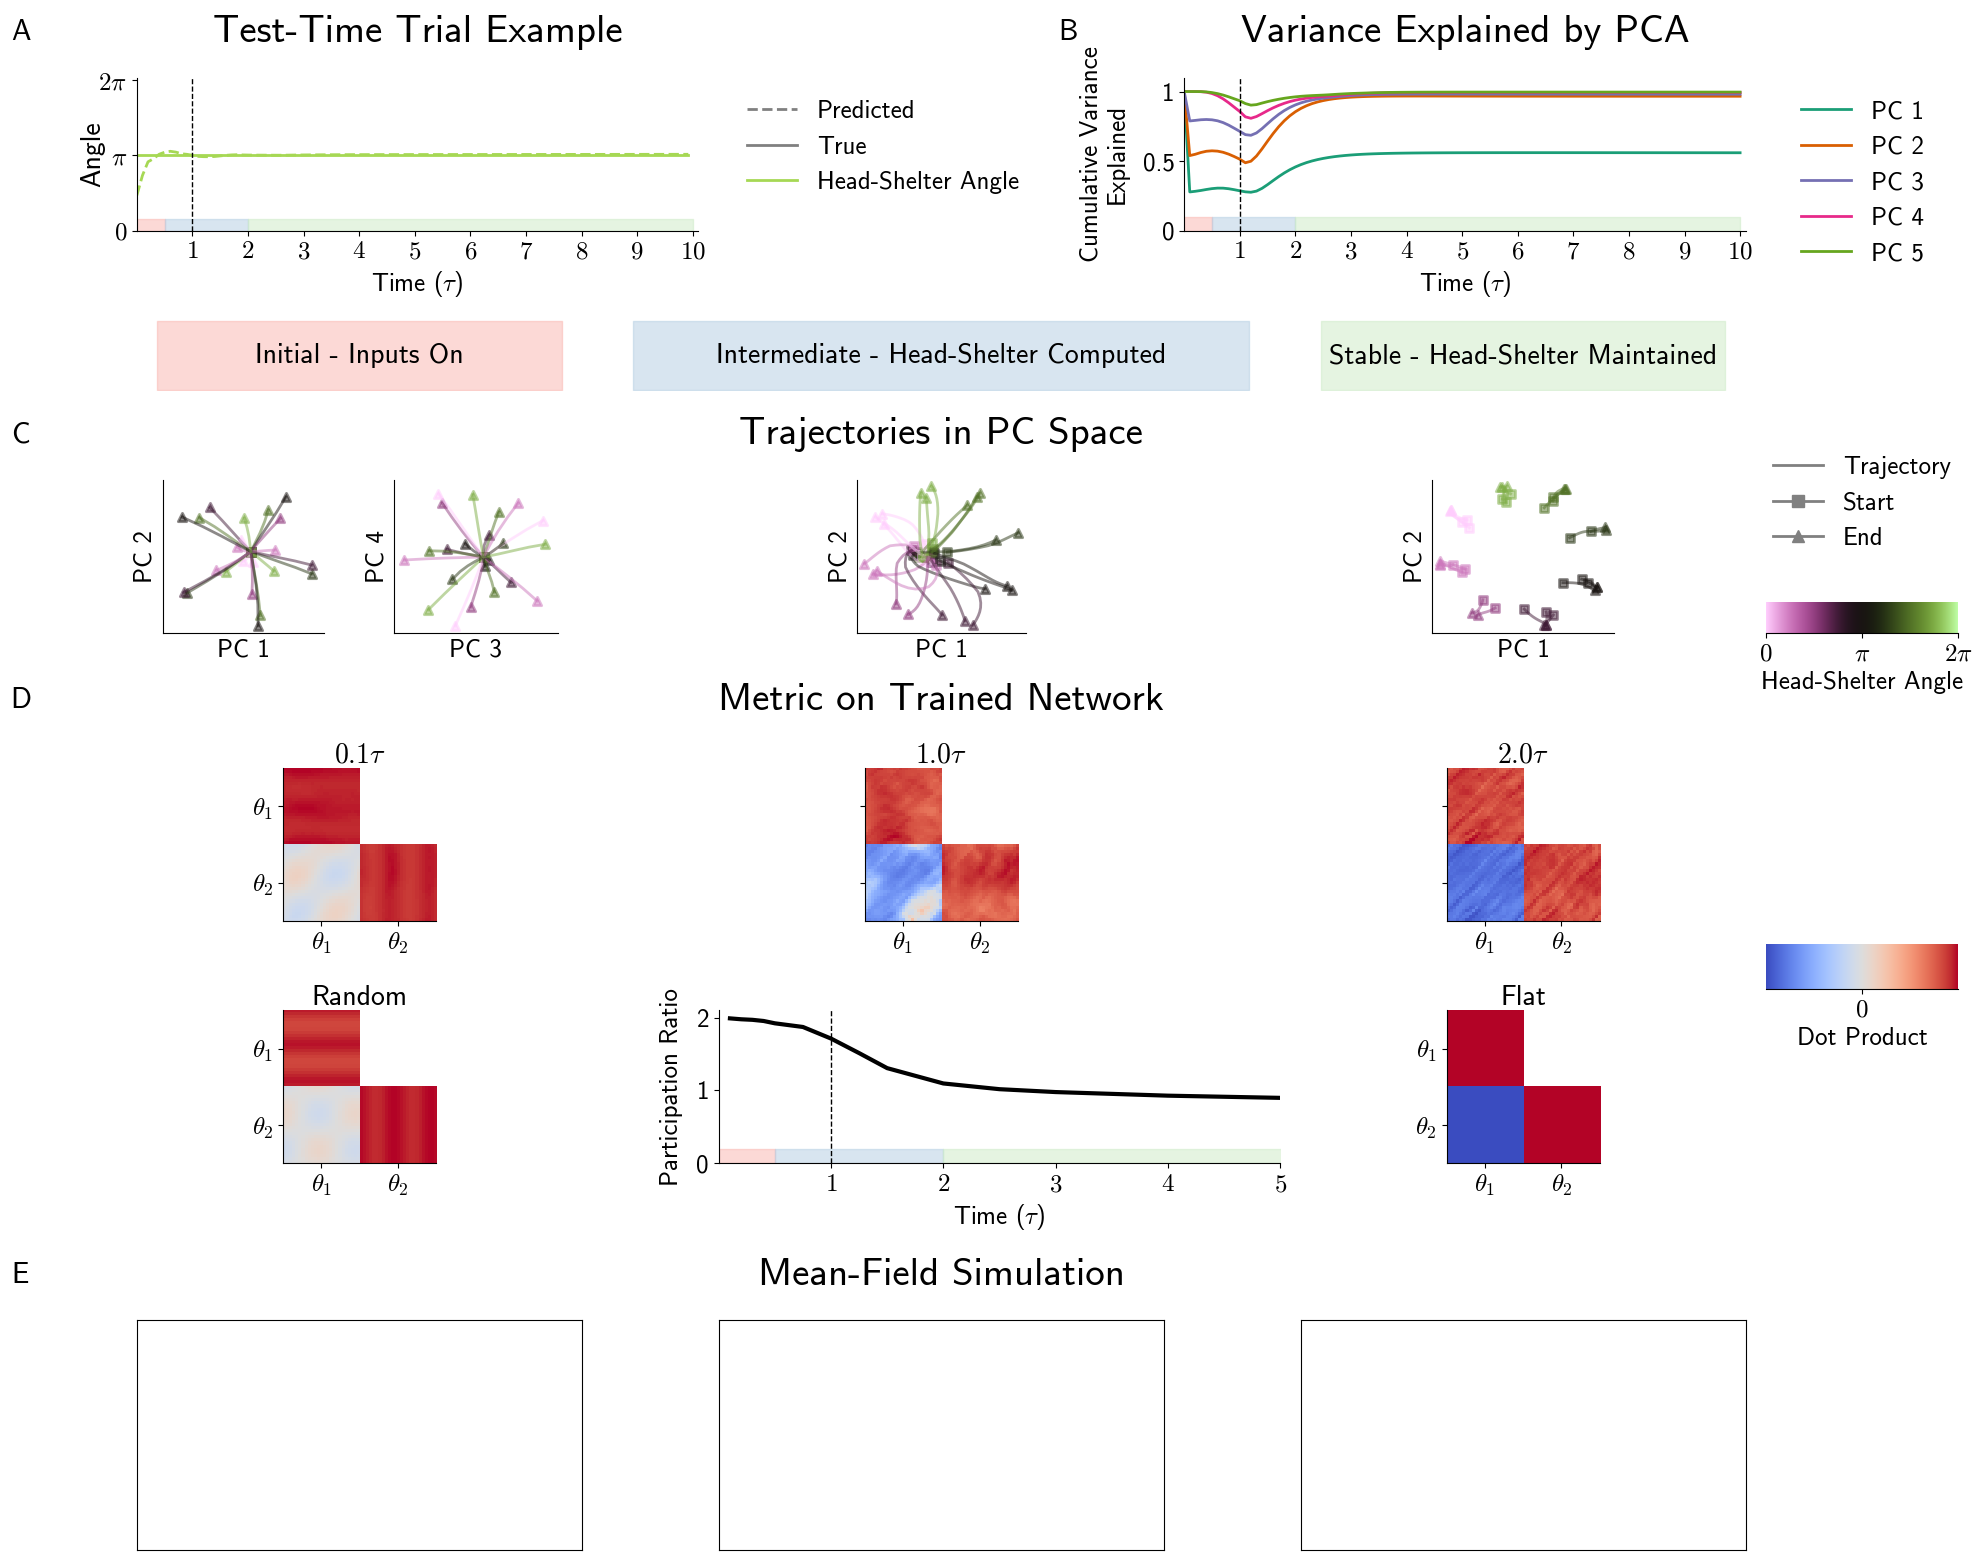

In [26]:
v_spacer = 0.3
h_spacer = 0.5

fig = plt.figure(figsize=(25, 20))
gs = fig.add_gridspec(12, 16, 
    height_ratios=[v_spacer, 1, v_spacer*3, v_spacer, 1, 2*v_spacer, 1, v_spacer, 1, v_spacer, v_spacer, 1.5], 
    width_ratios=[1 for _ in range(15)] + [2])

A_top_row = 0
A_bottom_row = 1
A_left_col = 0
A_right_col = 5

B_top_row = 0
B_bottom_row = 2
B_left_col = 9
B_right_col = 14

C_top_row = 3
C_bottom_row = 4
C_left_col = 0
C_right_col = 14

D_top_row = 5
D_bottom_row = 8
D_left_col = 0
D_right_col = 14

E_top_row = 10
E_bottom_row = 11
E_left_col = 0
E_right_col = 14

period_title_row = 2
init_left_col = 1
init_right_col = 4
inter_left_col = 5
inter_right_col = 10
stable_left_col = 11
stable_right_col = 14

def make_title(letter, title, top, left, right):
    letter_ax = fig.add_subplot(gs[top, left])
    letter_ax.text(0, 0.5, letter, fontsize=letter_fontsize, fontweight='bold', ha='center', va='center', rotation=0)
    letter_ax.set_xlim([0,1])
    letter_ax.axis('off')
    title_ax = fig.add_subplot(gs[top, left+1:right+1])
    title_ax.text(0.5, 0.5, title, fontsize=title_fontsize, fontweight='regular', ha='center', va='center')
    title_ax.set_xlim([0,1])
    title_ax.axis('off')


make_title('A', 'Test-Time Trial Example', A_top_row, A_left_col, A_right_col)
A_data_ax = fig.add_subplot(gs[A_top_row+1, A_left_col+1:A_right_col+1])

A_data_ax.plot(sd_0d_test_sd_pred_x, sd_0d_test_sd_pred_y, lw=2, linestyle='--', color=sd_col)
A_data_ax.plot(sd_0d_test_sd_target_x, sd_0d_test_sd_target_y, lw=2, linestyle='-', color=sd_col)
A_data_ax.axvline(x=1, color='k', linestyle='--', lw=1)
A_data_ax.set_xticks([i+1 for i in range(10)])
A_data_ax.set_xticklabels([fr'${i+1}$' for i in range(10)], fontsize=tick_fontsize)
A_data_ax.set_xlim([0, 10.1])
A_data_ax.set_xlabel(r'Time ($\tau$)', fontsize=tick_fontsize)
A_data_ax.set_yticks([0, np.pi, 2*np.pi])
A_data_ax.set_ylim([0, 2*np.pi + 0.1])
A_data_ax.set_yticklabels([r'$0$', r'$\pi$', r'$2\pi$'], fontsize=tick_fontsize)
A_data_ax.fill_between(sd_0d_initial_pca_period, 0, 0.5, color=cat_cmap_2(0), alpha=0.5)
A_data_ax.fill_between(sd_0d_inter_pca_period, 0, 0.5, color=cat_cmap_2(1), alpha=0.5)
A_data_ax.fill_between(sd_0d_stable_pca_period, 0, 0.5, color=cat_cmap_2(2), alpha=0.5)
A_data_ax.set_ylabel('Angle', fontsize=label_fontsize, ha='center', va='center', rotation=90)

A_legend_ax = fig.add_subplot(gs[A_bottom_row, A_right_col+1:B_left_col])
A_handles = [
    matplotlib.lines.Line2D([0], [0], lw=2, linestyle='--', color='gray', label='Predicted'),
    matplotlib.lines.Line2D([0], [0], lw=2, linestyle='-', color='gray', label='True'),
    matplotlib.lines.Line2D([0], [0], lw=2, linestyle='-', color=sd_col, label='Head-Shelter Angle'),
]
A_legend_ax.legend(handles=A_handles, loc='upper center', fontsize=legend_fontsize, frameon=False, ncol=1)
A_legend_ax.axis('off')

make_title('B', 'Variance Explained by PCA', B_top_row, B_left_col, B_right_col)
B_data_ax = fig.add_subplot(gs[B_top_row+1, B_left_col+1:B_right_col+1])

T = np.linspace(0, 10, sd_0d_joint_pca_results.shape[0])
sd_max_dim = 4
for i in range(sd_max_dim+1):
    B_data_ax.plot(T, sd_0d_joint_pca_results[:, i], lw=2, color=cat_cmap(i))
B_data_ax.axvline(x=1, color='k', linestyle='--', lw=1)
B_data_ax.set_xticks([i+1 for i in range(10)])
B_data_ax.set_xticklabels([fr'${i+1}$' for i in range(10)], fontsize=tick_fontsize)
B_data_ax.set_xlim([0, 10.1])
B_data_ax.set_yticks([0, 0.5, 1])
B_data_ax.set_yticklabels(['0', '0.5', '1'], fontsize=tick_fontsize)
B_data_ax.set_ylim([0, 1.1])
B_data_ax.set_xlabel(r'Time ($\tau$)', fontsize=tick_fontsize)
B_data_ax.set_ylabel('Cumulative Variance\nExplained', fontsize=tick_fontsize, labelpad=10)
B_data_ax.fill_between(sd_0d_initial_pca_period, 0, 0.1, color=cat_cmap_2(0), alpha=0.5)
B_data_ax.fill_between(sd_0d_inter_pca_period, 0, 0.1, color=cat_cmap_2(1), alpha=0.5)
B_data_ax.fill_between(sd_0d_stable_pca_period, 0, 0.1, color=cat_cmap_2(2), alpha=0.5)

B_legend_ax = fig.add_subplot(gs[B_top_row+1:B_bottom_row+1, B_right_col+1])
B_handles = [
    matplotlib.lines.Line2D([0], [0], lw=2, linestyle='-', color=cat_cmap(i), label=f'PC {i+1}') for i in range(sd_max_dim+1)
]
B_legend_ax.legend(handles=B_handles, loc='upper center', fontsize=legend_fontsize, frameon=False, ncol=1)
B_legend_ax.axis('off')

init_title_ax = fig.add_subplot(gs[period_title_row, init_left_col:init_right_col+1])
init_title_ax.fill_between([0, 1], [1, 1], color=cat_cmap_2(0), alpha=0.5)
init_title_ax.text(0.5, 0.5, 'Initial - Inputs On', fontsize=label_fontsize, ha='center', va='center')
init_title_ax.set_ylim([0, 2])
init_title_ax.axis('off')

inter_title_ax = fig.add_subplot(gs[period_title_row, inter_left_col:inter_right_col+1])
inter_title_ax.fill_between([0, 1], [1, 1], color=cat_cmap_2(1), alpha=0.5)
inter_title_ax.text(0.5, 0.5, 'Intermediate - Head-Shelter Computed', fontsize=label_fontsize, ha='center', va='center')
inter_title_ax.set_ylim([0, 2])
inter_title_ax.axis('off')

stable_title_ax = fig.add_subplot(gs[period_title_row, stable_left_col:stable_right_col+1])
stable_title_ax.fill_between([0, 1], [1, 1], color=cat_cmap_2(2), alpha=0.5)
stable_title_ax.text(0.5, 0.5, 'Stable - Head-Shelter Maintained', fontsize=label_fontsize, ha='center', va='center')
stable_title_ax.set_ylim([0, 2])
stable_title_ax.axis('off')

make_title('C', 'Trajectories in PC Space', C_top_row, C_left_col, C_right_col)

for i, period_proj in enumerate([sd_0d_initial_pca_projection, sd_0d_inter_pca_projection, sd_0d_stable_pca_projection]):
    var, cmap = sd_0d_proj_joint_batch['vars']['sd'], sd_cmap
    for k, (pc_x, pc_y) in enumerate(zip([0, 2], [1, 3])):
        if i > 0 and k > 0:
            continue
        inset = 0 if i==0 else (6 if i==1 else 11)
        ax = fig.add_subplot(gs[C_top_row+1, C_left_col+1 + inset + 2*k : C_left_col+1 + inset + 2*(k+1)])

        for b in range(0, period_proj.shape[0], 3):
            var_val = var[b,0].cpu()
            ax.plot(period_proj[b, :, pc_x], period_proj[b, :, pc_y], lw=2, color=cmap(var_val/(2*np.pi)), alpha=0.5)
            ax.scatter(period_proj[b, 0, pc_x], period_proj[b, 0, pc_y], lw=2, color=cmap(var_val/(2*np.pi)), alpha=0.5, marker='s')
            ax.scatter(period_proj[b, -1, pc_x], period_proj[b, -1, pc_y], lw=2, color=cmap(var_val/(2*np.pi)), alpha=0.5, marker='^')
        ax.set_aspect('equal')
        ax.set_xticks([])
        ax.set_xlabel(f'PC {pc_x+1}', fontsize=tick_fontsize)
        ax.set_yticks([])
        ax.set_ylabel(f'PC {pc_y+1}', fontsize=tick_fontsize)
        ax.set_xlim([np.min(period_proj[:, :, pc_x])*1.1, np.max(period_proj[:, :, pc_x])*1.1])
        ax.set_ylim([np.min(period_proj[:, :, pc_y])*1.1, np.max(period_proj[:, :, pc_y])*1.1])

C_legend_ax = fig.add_subplot(gs[C_top_row+1, -1])
gradient = np.linspace(0, 1, 256).reshape(1, -1)
C_legend_ax.imshow(gradient, aspect='auto', cmap=sd_cmap,
                   extent=[0, 1, 0, 0.2])
C_legend_ax.set_yticks([])
C_legend_ax.set_ylim([0,1])
C_legend_ax.set_xticks([0, 0.5, 1])
C_legend_ax.set_xticklabels([r'$0$', r'$\pi$', r'$2\pi$'], fontsize=tick_fontsize)
C_legend_ax.set_xlabel('Head-Shelter Angle', fontsize=legend_fontsize)
C_handles = [
    # plain trajectory line
    matplotlib.lines.Line2D([], [], color='grey', lw=2, label='Trajectory'),

    # line that starts with a square marker
    matplotlib.lines.Line2D([0, 0.5, 1], [0, 0, 0], color='grey', lw=2,
           marker='s', markersize=8, markerfacecolor='grey',
           markeredgecolor='grey', markevery=[0], label='Start'),

    # line that ends with a triangle marker
    matplotlib.lines.Line2D([0, 0.5, 1], [0, 0, 0], color='grey', lw=2,
           marker='^', markersize=8, markerfacecolor='grey',
           markeredgecolor='grey', markevery=[-1], label='End'),
]
C_legend_ax.legend(handles=C_handles, loc='upper center',
                   fontsize=legend_fontsize, frameon=False, ncol=1, bbox_to_anchor=(0.5, 1.3))
C_legend_ax.spines['left'].set_visible(False)

make_title('D', 'Metric on Trained Network', D_top_row, D_left_col, D_right_col)

n_samples = sd_0d_av_metric_results['params']['n_samples']
show_i = [0, 6, 9]
cols = [(init_left_col, init_left_col+3), (inter_left_col+1, inter_left_col+4), (stable_left_col, stable_left_col+3)]
for i, t in zip(show_i, np.array(select_tau)[show_i]):
    left_col, right_col = cols[show_i.index(i)]
    ax = fig.add_subplot(gs[D_top_row+1, left_col:right_col+1])

    vmax = np.nanmax(np.abs(sd_0d_av_metric_results['metric'][i]))
    norm = matplotlib.colors.SymLogNorm(linthresh=1, linscale=0.1, vmin=-vmax, vmax=vmax)
    # vmax = 1
    # norm = matplotlib.colors.Normalize(vmin=-vmax, vmax=vmax, clip=True)

    metric = sd_0d_av_metric_results['metric'][i]
    metric = metric[:2*n_samples]
    metric = metric[:, :2*n_samples]

    ax.imshow(metric, aspect='auto', cmap='coolwarm', interpolation='nearest', norm=norm)
    ax.set_xticks([int(n_samples * (1/2)), int(n_samples * (3/2))])
    ax.set_xticklabels([r'$\theta_1$', r'$\theta_2$'], fontsize=tick_fontsize)
    ax.set_yticks([int(n_samples * (1/2)), int(n_samples * (3/2))])
    if i==0:
        ax.set_yticklabels([r'$\theta_1$', r'$\theta_2$'], fontsize=tick_fontsize)
    else:
        ax.set_yticklabels(['' for _ in range(2)], fontsize=tick_fontsize)
    ax.set_aspect('equal')
    ax.set_title(rf'${t:.1f}\tau$', fontsize=label_fontsize, ha='center', va='center')

# D_legend_ax = fig.add_subplot(gs[D_top_row+1, -1])
# D_legend_ax.imshow(gradient, aspect='auto', cmap='coolwarm',
#                    extent=[-1, 1, 0, 0.2])
# D_legend_ax.set_yticks([])
# D_legend_ax.set_ylim([0, 1])
# D_legend_ax.set_xticks([0])
# D_legend_ax.set_xticklabels([r'$0$'], fontsize=tick_fontsize)
# D_legend_ax.set_xlabel('Dot Product', fontsize=legend_fontsize)
# D_legend_ax.spines['left'].set_visible(False)


random_ax = fig.add_subplot(gs[D_bottom_row, D_left_col+2:D_left_col+4])
random_norm = matplotlib.colors.Normalize(vmin=-np.nanmax(np.abs(random_metric)), vmax=np.nanmax(np.abs(random_metric)))
random_ax.imshow(random_metric, aspect='auto', cmap='coolwarm', interpolation='nearest', norm=random_norm)
random_ax.set_xticks([int(n_samples * (1/2)), int(n_samples * (3/2))])
random_ax.set_xticklabels([r'$\theta_1$', r'$\theta_2$'], fontsize=tick_fontsize)
random_ax.set_yticks([int(n_samples * (1/2)), int(n_samples * (3/2))])
random_ax.set_yticklabels([r'$\theta_1$', r'$\theta_2$'], fontsize=tick_fontsize)
random_ax.set_aspect('equal')
random_ax.set_title(r'Random', fontsize=label_fontsize, ha='center', va='center')

flat_ax = fig.add_subplot(gs[D_bottom_row, D_right_col-2:D_right_col])
flat_norm = matplotlib.colors.Normalize(vmin=-np.nanmax(np.abs(flat_metric)), vmax=np.nanmax(np.abs(flat_metric)))
flat_ax.imshow(flat_metric, aspect='auto', cmap='coolwarm', interpolation='nearest', norm=flat_norm)
flat_ax.set_xticks([int(n_samples * (1/2)), int(n_samples * (3/2))])
flat_ax.set_xticklabels([r'$\theta_1$', r'$\theta_2$'], fontsize=tick_fontsize)
flat_ax.set_yticks([int(n_samples * (1/2)), int(n_samples * (3/2))])
flat_ax.set_yticklabels([r'$\theta_1$', r'$\theta_2$'], fontsize=tick_fontsize)
flat_ax.set_aspect('equal')
flat_ax.set_title(r'Flat', fontsize=label_fontsize, ha='center', va='center')

tick_tau = [1, 2, 3, 4, 5]
PR_ax = fig.add_subplot(gs[D_bottom_row, D_left_col+6:D_right_col-3])
PR_ax.plot(select_tau, metric_PR, lw=3, color='k')
PR_ax.axvline(x=1, color='k', linestyle='--', lw=1)
PR_ax.set_xticks(tick_tau)
PR_ax.set_xticklabels([fr'${t}$' for t in tick_tau], fontsize=tick_fontsize)
PR_ax.set_xlim([0, tick_tau[-1]])
PR_ax.set_yticks([0, 1, 2])
PR_ax.set_yticklabels(['0', '1', '2'], fontsize=tick_fontsize)
PR_ax.set_ylim([0, 2.1])
PR_ax.set_xlabel(r'Time ($\tau$)', fontsize=tick_fontsize)
PR_ax.set_ylabel('Participation Ratio', fontsize=tick_fontsize, labelpad=10)
PR_ax.fill_between(sd_0d_initial_pca_period, 0, 0.2, color=cat_cmap_2(0), alpha=0.5)
PR_ax.fill_between(sd_0d_inter_pca_period, 0, 0.2, color=cat_cmap_2(1), alpha=0.5)
PR_ax.fill_between(sd_0d_stable_pca_period, 0, 0.2, color=cat_cmap_2(2), alpha=0.5)

D_legend_ax = fig.add_subplot(gs[D_top_row+1:D_bottom_row, -1])
D_legend_ax.imshow(gradient, aspect='auto', cmap='coolwarm',
                   extent=[-1, 1, 0, 0.2])
D_legend_ax.set_yticks([])
D_legend_ax.set_ylim([0, 1])
D_legend_ax.set_xticks([0])
D_legend_ax.set_xticklabels([r'$0$'], fontsize=tick_fontsize)
D_legend_ax.set_xlabel('Dot Product', fontsize=legend_fontsize)
D_legend_ax.spines['left'].set_visible(False)

make_title('E', 'Mean-Field Simulation', E_top_row, E_left_col, E_right_col)

for i in range(3):
    bounds = [(1, 5), (6, 10), (11, 15)][i]
    ax = fig.add_subplot(gs[E_top_row+1, bounds[0]:bounds[1]])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines['right'].set_visible(True)
    ax.spines['top'].set_visible(True)
    # ax.set_axis_off()


In [27]:
fig.savefig("cosyne-f2.pdf", format="pdf", bbox_inches='tight')

# Submission